## Adding boundary conditions to the simulation

This is theory notebook 3/4. See the previous ones for the basic simulation code and collision physics.

In this notebook we develop boundary conditions for the simulation. There are 3 options we will implement to choose from in a simulation:
1. The objects move around freely and can go out infinitely far. This is what we have been doing so far in the previous notebooks. (No/infinite box.)
2. The objects are placed within a box and bounce off its walls[<sup>*</sup>](#fn1).  (Finite box.)
3. The objects are placed within a box, but we set this up following the so-called minimal image convention. Here, we effectively simulate an infinite system of objects by placing periodic copies of the volume we are simulating around its borders. Objects moving out of the box will reappear on the other side. Objects interact with other objects only through the one copy that is closest to them. A more detailed explanation follows below. (Periodic box.)

These options cover many systems one could dream of simulating, although there are additional options, like removing particles that move outside of the box, or applying a force outside of the box. We'll stick with these three though, as I believe they are the most common.

<span id="fn1">*Admittedly, it is somewhat silly to consider a system where gravity is the relevant driving force to be placed within a box, but for other forces (like between gas molecules) this is a more realistic scenario, so we also add it here for completeness.</span>

In [3]:
# Define the simulation code functions we already have
import numpy as np
import matplotlib.pyplot as plt

G = 1
dt = 1e-3  # timestep
e = 0.8  # coefficient of restitution

def gravity_force(m_i, m_j, r_i, r_j):
    """
    Calculate the gravitational force exerted on object i by object j.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - r_i (np.array): Position vector of object i
        - r_j (np.array): Position vector of object j
    """
    r_ij = r_i - r_j
    distance = np.linalg.norm(r_ij)
    unit_r_ij = r_ij / distance
    return -G * m_i * m_j / distance**2 * unit_r_ij

def next_velocity(current_velocity, next_acceleration, current_acceleration):
    """
    Find the velocity at the next timestep using the Verlet integration method.
    Parameters:
        - current_velocity (np.array): Velocity at the current timestep
        - next_acceleration (np.array): Acceleration at the next timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_velocity + 0.5 * dt * (next_acceleration + current_acceleration)

def next_position(current_position, current_velocity, current_acceleration):
    """
    Find the position at the next timestep using the velocity Verlet integration method.
    Parameters:
        - current_position (np.array): Position at the current timestep
        - current_velocity (np.array): Velocity at the current timestep
        - current_acceleration (np.array): Acceleration at the current timestep
    """
    return current_position + current_velocity * dt + 0.5 * current_acceleration * dt**2

def galilean_transform(target_velocity, frame_velocity):
    """
    Perform a Galilean transformation.
    Parameters:
        - target_velocity (np.array): Velocity of the object that is to be transformed
        - frame_velocity (np.array): Velocity of the frame you want to transform to
    """
    return target_velocity - frame_velocity

def get_rotation_angles(position_i, position_j):
    """
    Calculate the rotation angles around the axes to align with 
    the line between the centres of the objects i and j.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
    Returns:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
    """
    difference = position_i - position_j  # (delta_x, delta_y, delta_z)
    # Using arctan2 ensures the right quadrant sign
    alpha = np.arctan2(difference[2], difference[1])
    beta = np.arctan2(difference[0], difference[2])
    gamma = np.arctan2(difference[1], difference[0])
    return alpha, beta, gamma

def rotation(alpha, beta, gamma, target_vector):
    """
    Perform a rotation around the x, y and z axis.
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(alpha)],
        [0, np.sin(alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(beta)],
        [0, 1, 0],
        [-np.sin(beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(gamma), 0],
        [np.sin(gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_x @ rotation_matrix_y @ rotation_matrix_z  # Note xyz
    return combined_rotation @ target_vector

def inverse_rotation(alpha, beta, gamma, target_vector):
    """
    Perform an inverse rotation around the x, y and z axis,
    compared to the function above. Note no minus sign on the
    angles is needed relative to above!
    Parameters:
        - alpha (float): Angle around the x axis
        - beta (float): Angle around the y axis
        - gamma (float): Angle around the z axis
        - target_vector (np.array): Vector you want to rotate
    """
    rotation_matrix_x = np.array([
        [1, 0, 0],
        [0, np.cos(alpha), -np.sin(-alpha)],
        [0, np.sin(-alpha), np.cos(alpha)]
    ])
    rotation_matrix_y = np.array([
        [np.cos(beta), 0, np.sin(-beta)],
        [0, 1, 0],
        [-np.sin(-beta), 0, np.cos(beta)]
    ])
    rotation_matrix_z = np.array([
        [np.cos(gamma), -np.sin(-gamma), 0],
        [np.sin(-gamma), np.cos(gamma), 0],
        [0, 0, 1]
    ])
    combined_rotation = rotation_matrix_z @ rotation_matrix_y @ rotation_matrix_x  # Note zyx
    return combined_rotation @ target_vector

def velocity_transfer_collision(m_i, m_j, velocity_before_i):
    """
    Calculate the velocity of object i and j after an (in)elastic
    collision, where i moves and j is stationary.
    Parameters:
        - m_i (float): Mass of object i
        - m_j (float): Mass of object j
        - velocity_before_i (np.array): Velocity of object i before the collision
    Returns:
        - velocity_after_i (np.array): Velocity of object i after the collision
        - velocity_after_j (np.array): Velocity of object j after the collision
    """
    velocity_after_i = (m_i - e * m_j) / (m_i + m_j) * velocity_before_i
    velocity_after_j = (1 + e) * m_i / (m_i + m_j) * velocity_before_i
    return velocity_after_i, velocity_after_j

def objects_move_towards_each_other(position_i, position_j, velocity_i, velocity_j):
    """
    Determine if objects i and j are moving towards each other, so that a collision 
    can happen. This is the case if for any of the components of the position and 
    velocity vectors, the position component of i is smaller and the velocity 
    component of i is larger, or vice versa.
    Parameters:
        - position_i (np.array): Position vector of object i
        - position_j (np.array): Position vector of object j
        - velocity_i (np.array): Velocity vector of object i
        - velocity_j (np.array): Velocity vector of object j
    Returns:
        - bool: True if objects move towards each other
    """
    position_mask = position_i > position_j
    velocity_mask = velocity_i > velocity_j
    # We need position_i to be smaller and velocity_i larger or vice versa,
    # meaning these masks do not have the same value
    collisions = position_mask != velocity_mask
    # If any of these is True, there will be a collision
    return np.any(collisions)

### 1. No box

This scenario is the same as we have already been doing, so we don't need to program anything new here. But I will show the parameters one needs to set to get this scenario. 

We introduce three new parameters: `box_length`, `periodic` and `e_wall`. In the other two scenarios, `box_length` has to be set to some value (in internal units) to determine when an object moves outside of the box, but here we will just set it to `None`. The parameter `periodic` is a simple boolean value we set to `True` for the third periodic box scenario and `False` for the other two. Finally, `e_wall` sets the coefficient of restitution for wall collisions, and is thus only relevant in the second finite box scenario, so we set it to `None` here.

In [4]:
# No box setup
box_length = None
periodic = False
e_wall = None

### 2. Finite box

Here we do have to specify a box length, which determines how large the box will be the objects move in. We will consider a cube, so that only one length needs to be given. We then centre the box on the origin, meaning the objects are confined to the space `[-0.5*box_length, 0.5*box_length]` for each axis. We also have to define a coefficient of restitution for the wall collisions.

In [5]:
# Finite box setup
box_length = 10
periodic = False
e_wall = 1.0  # coefficient of restitution for wall collisions

Now when the object moves to the edge of the box, it will hit a wall. This is essentially the same situation as the collision physics we implemented before, but where the object that gets hit has an infinite mass ($m_2 \rightarrow \infty$), which automatically results in its velocity staying zero, as we would like to see for a wall.

Since we already have the equations anyway, we'll also allow these wall collisions to be inelastic, set by its own coefficient of restitution $e_\mathrm{wall}$. Thus the velocity of the colliding object will be

\begin{equation}
\nonumber
    v'_1 = \lim_{m_2 \rightarrow \infty} \frac{m_1 - e_\mathrm{wall} m_2}{m_1 + m_2} v_1 = \lim_{m_2 \rightarrow \infty} \frac{m_1/m_2 - e_\mathrm{wall}}{m_1/m_2 + 1} v_1 = -e_\mathrm{wall} v_1 .
\end{equation}

Note that for $e_\mathrm{wall}=1$, we simply have an inversion of the sign of the velocity, as expected.

We will also include a check if an object is actually moving towards a wall before performing the collision calculations, for the same reason we checked if two objects are moving towards each other before: the object may not have moved away enough from the wall after a single timestep so that the collision calculation is triggered again while it should not. In this case, we check if both position and velocity components have the same sign (either positive or negative), as a positive position means the object would hit the `+0.5*box_length` side of the wall, meaning the velocity also needs to be positive to be moving in that direction; idem for the negative case. It is important to check this per vector component, as the three axes of collision act independently of each other, unlike for the objects colliding, where we rotate into a single axis.

While collisions between objects required Galilean transforms and rotations, here the wall is already stationary and collisions can only happen across one axis (although multiple could happen at one time, if the object hits a corner perfectly), so we only need to determine which component of the velocity we need to apply the change due to the collision to.

In [6]:
def velocity_transfer_collision_wall(velocity_before_i):
    """
    Calculate the velocity of object i after an (in)elastic
    collision with the wall.
    Parameters:
        - velocity_before_i (np.array): Velocity of object i before the collision
    Returns:
        - velocity_after_i (np.array): Velocity of object i after the collision
    """
    velocity_after_i = -e_wall * velocity_before_i
    return velocity_after_i

def wall_collision_check_and_transfer(position_i, velocity_i):
    """
    Check if the object is colliding for each axis/component,
    and apply the velocity transfer if so.
    Parameters:
        - position_i (np.array): Position vector of object i
        - velocity_i (np.array): Velocity vector of object i
    Returns:
        - velocity_after_i (np.array): Velocity vector of object i after wall collision
    """
    walls = 0.5*np.array([box_length]*3)
    # Find where the object is outside the box
    where_cross = np.logical_or(position_i > walls, position_i < -walls)

    # Determine if a collision can happen, if the object moves towards the wall
    collisions = (position_i > 0) == (velocity_i > 0)

    # Apply velocity transfer where both conditions are met per component
    velocity_after_i = np.where(
        np.logical_and(where_cross, collisions),
        velocity_transfer_collision_wall(velocity_i),
        velocity_i
    )
    return velocity_after_i

We will add this to the simulation loop after having also set up the last scenario.

### 3. Periodic box

Here we also specify the box length, but now a particle loops around to the other side when it moves outside of these boundaries. This makes the coefficient of restitution for wall collisions irrelevant. Additionally, we set `periodic=True`.

In [7]:
# Periodic box setup
box_length = 10
periodic = True
e_wall = None

function to determine minimal image copy to calculate force with; to bring particles to other side of box; NOT to check moving towards wall, as velocity is never changed here, so no problems there

Now let's take a more detailed look at this periodic boundary condition, with the minimal image convention. The idea is that we want to simulate a very large, or you might say infinite, system. This is relevant when you consider e.g. a gas, whether it is a large hydrogen cloud contracting through gravity or just the air in a room with particles bumping into each other, because this system contains far too many particles to simulate normally (say order $N_A \sim 10^{23}$). So instead, we might zoom in on a part of this gas that only contains a more reasonable amount of objects, which is embedded in a seemingly infinite system. To achieve this, we can use the minimal image convention. Here we make "copies" of the volume we are simulating and stick those on the other side of its boundaries. A simpler 2D visualization of this can be seen below.

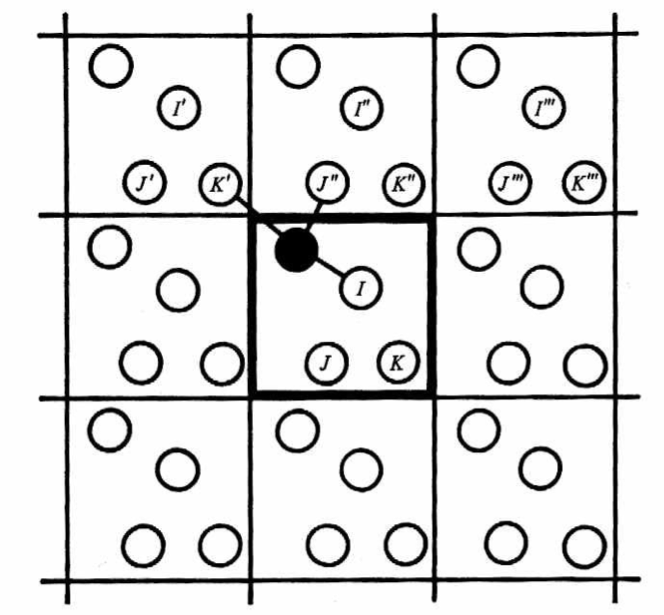

Image from: https://www.researchgate.net/figure/lustration-of-the-periodic-boundary-conditions-PBC-method-with-the-minimum-image_fig9_279264054

If a particle moves outside of the simulated volume, we can see this as the copy of that particle entering the simulated volume from the opposite side, so that effectively the particle loops around and enters the simulated volume again.

A key part of simulating an "infinite" system is how we calculate the forces arising from interactions between the objects. As also shown in the image, we do not compare a given object with all other objects in the same box, but instead take the copy of every other object that is closest to the given object. (In the image, $K'$ is closer than $K$ and $J''$ is closer than $J$.) This way the objects interact as if there are really more objects beyond the boundaries.

In [8]:
def closest_copy_coordinates(position_i, positions):
    """
    Find the coordinates of the closest copy of each object relative to
    the object i according to the minimal image convention.
    Parameters:
        - position_i (np.array): Position vector of object i
        - positions (np.array): Array of position vectors of all objects
    Returns:
        - copy_positions (np.array): Array of position vectors of the closest copies of all objects
    """
    copy_positions = position_i -  (position_i - positions + 0.5*box_length) % box_length + 0.5*box_length
    return copy_positions

def apply_periodic_crossing(position_i):
    """
    Check if an object has crossed the periodic boundary, 
    and apply the correction in position if so.
    Parameters:
        - position_i (np.array): Position vector of object i
    Returns:
        - crossed_positions (np.array): Position vector of object i after applying periodic crossing correction
    """
    crossed_positions = np.copy(position_i)
    where_cross_positive = position_i > 0.5*box_length
    where_cross_negative = position_i < -0.5*box_length
    crossed_positions[where_cross_positive] -= box_length
    crossed_positions[where_cross_negative] += box_length
    return crossed_positions

# Checks
print("Box boundaries at:", 0.5*box_length)

positions = np.array([
    [4, 4, 0],
    [-4, -4, 0],
    [4, -4, 0],
    [-4, 4, 0],
    [3, 3, 0]
])
copy_positions = closest_copy_coordinates(positions[0], positions)
print("Original positions:\n", positions)
print("Closest copy positions, relative to object 1:\n", copy_positions)

positions2 = np.array([
    [6, 3, -1],
    [-9, 12, 0]
])
crossed_positions = apply_periodic_crossing(positions2)
print("Original positions:\n", positions2)
print("Positions after applying periodic crossing:\n", crossed_positions)
# All checks out! Note the closest copies are outside of the boundaries where relevant

Box boundaries at: 5.0
Original positions:
 [[ 4  4  0]
 [-4 -4  0]
 [ 4 -4  0]
 [-4  4  0]
 [ 3  3  0]]
Closest copy positions, relative to object 1:
 [[4. 4. 0.]
 [6. 6. 0.]
 [4. 6. 0.]
 [6. 4. 0.]
 [3. 3. 0.]]
Original positions:
 [[ 6  3 -1]
 [-9 12  0]]
Positions after applying periodic crossing:
 [[-4  3 -1]
 [ 1  2  0]]


Now we can add these three scenarios into the main simulation loop algorithm.

In [26]:
# Initial conditions periodic box
box_length = 10
periodic = True
e_wall = None
N_steps = 10000
times = np.arange(N_steps) * dt
N_objects = 3

# Make an array with the mass and radius of each object
masses = np.array([1, 1, 1])
radii = np.array([0.1, 0.1, 0.1])

# Make an array 'positions' to mark the positions of the objects
# Here positions[i] are the positions of all objects at timestep i,
# positions[i][j] is the position of object j at timestep i,
# positions[i][j][k] is the k-coordinate of object j at timestep i.
positions = np.zeros(shape=[N_steps, N_objects, 3])  # 3 for x, y, z coordinates

# Choose initial positions
positions[0][0] = np.array([4,4,0])
positions[0][1] = np.array([-4,4,0])
positions[0][2] = np.array([4,-4,0])

# Make an array 'velocities' to mark the velocities of the objects
# with the same structure as positions
velocities = np.zeros(shape=[N_steps, N_objects, 3])

# Choose initial velocities
velocities[0][0] = np.array([0,0,0])
velocities[0][1] = np.array([0,0,0])
velocities[0][2] = np.array([0,0,0])

In [27]:
# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
previous_accelerations = np.zeros(shape=[N_objects, 3])

# Then also determine acceleration for step 0
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j

    if periodic:  # get closest copy positions for object j
        copy_positions = closest_copy_coordinates(positions[0][j], positions[0])

    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            # Check for periodic box
            if not periodic:
                force += gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
            else:  # Apply minimal image convention
                force += gravity_force(masses[j], masses[k], positions[0][j], copy_positions[k])
    previous_accelerations[j] = force / masses[j]  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    for j in range(N_objects):
        # Update positions, with the already calculated previous acceleration
        positions[i][j] = next_position(positions[i-1][j], velocities[i-1][j], previous_accelerations[j])
    
    # Once all positions are updated, calculate new accelerations and update velocities
    for j in range(N_objects):
        force = np.zeros(3)  # to add up all forces on object j

        if periodic:  # get closest copy positions for object j
            copy_positions = closest_copy_coordinates(positions[i][j], positions[i])

        for k in range(N_objects):
            # Consider all other objects k, so without k==j
            if k != j:
                # Check for periodic box
                if not periodic:
                    force += gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
                else:  # Apply minimal image convention
                    force += gravity_force(masses[j], masses[k], positions[i][j], copy_positions[k])
        acceleration = force / masses[j]

        # So update velocities
        velocities[i][j] = next_velocity(velocities[i-1][j], acceleration, previous_accelerations[j])
        # And update the previous acceleration for the next loop
        previous_accelerations[j] = acceleration
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k
    
    # Boundary conditions
    if box_length is None:
        continue  # no boundary conditions, so skip to next timestep

    for j in range(N_objects):
        # Check if the object is outside the box
        if np.any(np.abs(positions[i][j]) > 0.5*box_length):
            # Check finite or periodic box
            if not periodic:
                velocities[i][j] = wall_collision_check_and_transfer(positions[i][j], velocities[i][j])
            else:
                positions[i][j] = apply_periodic_crossing(positions[i][j])

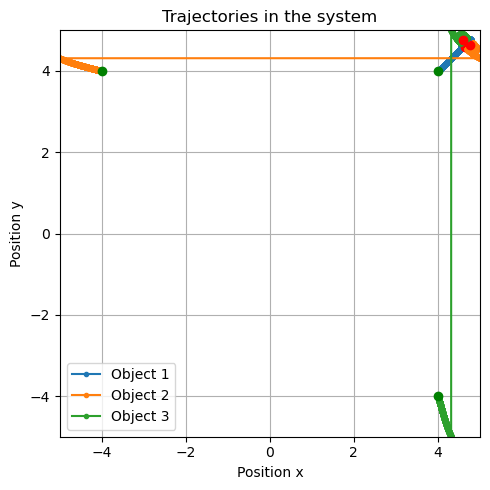

In [28]:
# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
plt.legend()
plt.grid()
plt.xlim(-0.5*box_length, 0.5*box_length)
plt.ylim(-0.5*box_length, 0.5*box_length)
plt.tight_layout()
plt.show()

This is the effect we wanted: objects start out into corners, such that according to the infinite box scenario we used before, they should all be pulled towards the middle of the plot. Due to the periodic box and minimal image convention, we however get the effect that actually the 'middle' between these objects is around (5,5,0), from object 1's point of view, so that they are all pulled that way. The second and third object cross into the other side of the box after passing the boundary. The resulting collisions once the objects get together can be seen in more detail below, so that also still works properly.

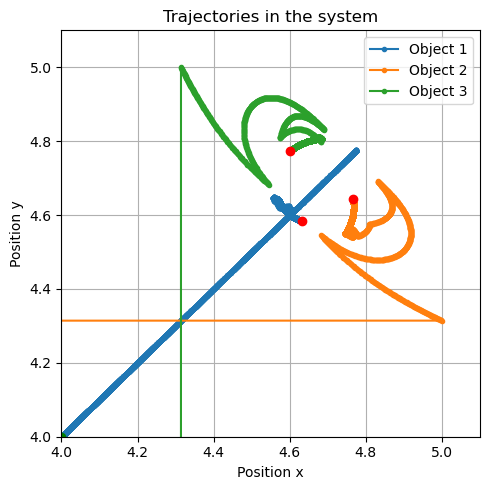

In [29]:
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
plt.legend()
plt.grid()
plt.xlim(4, 5.1)
plt.ylim(4, 5.1)
plt.tight_layout()
plt.show()

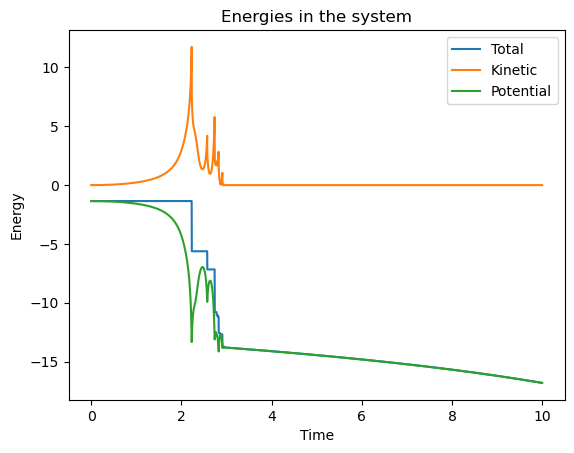

In [30]:
# Check energies; here the potential energy also changes with the minimal image convention
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    
    for k in range(j+1, N_objects):  # start from the object after j
        if not periodic:
            r_k = positions[:,k,:]
            distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timestep
        else:  # Apply minimal image convention
            copy_r_k = closest_copy_coordinates(r_j, positions[:,k,:])
            distance = np.linalg.norm(r_j - copy_r_k, axis=1)
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

The energy plots also look good. Note that there are no jumps in the potential energy because an object moved to the other side of the simulated volume suddenly (any jumps you do see are caused be the inelastic collisions; setting `e=1.0` proves this, but the resulting trajectories are more messy there, so we keep this example here).

Let's then also test the finite box scenario, where we'll set the initial velocities to make the objects hit the walls, and the masses small such that gravity is negligible. We also consider perfectly elastic collisions for simplicity, both with the wall and between objects. We use the same simulation loop, of course.

In [44]:
box_length = 10
periodic = False
e_wall = 1.0
N_steps = 10000
times = np.arange(N_steps) * dt
N_objects = 3
e = 1.0

# Make an array with the mass and radius of each object
masses = np.array([0.01, 0.01, 0.01])
radii = np.array([0.1, 0.1, 0.1])

# Make an array 'positions' to mark the positions of the objects
# Here positions[i] are the positions of all objects at timestep i,
# positions[i][j] is the position of object j at timestep i,
# positions[i][j][k] is the k-coordinate of object j at timestep i.
positions = np.zeros(shape=[N_steps, N_objects, 3])  # 3 for x, y, z coordinates

# Choose initial positions
positions[0][0] = np.array([4,4,0])
positions[0][1] = np.array([-4,4,0])
positions[0][2] = np.array([4,-4,0])

# Make an array 'velocities' to mark the velocities of the objects
# with the same structure as positions
velocities = np.zeros(shape=[N_steps, N_objects, 3])

# Choose initial velocities
velocities[0][0] = np.array([-1,-1,0])
velocities[0][1] = np.array([1,1,0])
velocities[0][2] = np.array([1,1,0])

In [45]:
# Also need to keep the previous acceleration for velocity
# Note we don't save these for all timesteps, only the previous one
previous_accelerations = np.zeros(shape=[N_objects, 3])

# Then also determine acceleration for step 0
for j in range(N_objects):
    force = np.zeros(3)  # to add up all forces on object j

    if periodic:  # get closest copy positions for object j
        copy_positions = closest_copy_coordinates(positions[0][j], positions[0])

    for k in range(N_objects):
        # Consider all other objects k, so without k==j
        if k != j:
            # Check for periodic box
            if not periodic:
                force += gravity_force(masses[j], masses[k], positions[0][j], positions[0][k])
            else:  # Apply minimal image convention
                force += gravity_force(masses[j], masses[k], positions[0][j], copy_positions[k])
    previous_accelerations[j] = force / masses[j]  # update these to contain step 0 accelerations

# Main simulation loop
for i in range(1, N_steps):  # 0 set by initial conditions
    for j in range(N_objects):
        # Update positions, with the already calculated previous acceleration
        positions[i][j] = next_position(positions[i-1][j], velocities[i-1][j], previous_accelerations[j])
    
    # Once all positions are updated, calculate new accelerations and update velocities
    for j in range(N_objects):
        force = np.zeros(3)  # to add up all forces on object j

        if periodic:  # get closest copy positions for object j
            copy_positions = closest_copy_coordinates(positions[i][j], positions[i])

        for k in range(N_objects):
            # Consider all other objects k, so without k==j
            if k != j:
                # Check for periodic box
                if not periodic:
                    force += gravity_force(masses[j], masses[k], positions[i][j], positions[i][k])
                else:  # Apply minimal image convention
                    force += gravity_force(masses[j], masses[k], positions[i][j], copy_positions[k])
        acceleration = force / masses[j]

        # So update velocities
        velocities[i][j] = next_velocity(velocities[i-1][j], acceleration, previous_accelerations[j])
        # And update the previous acceleration for the next loop
        previous_accelerations[j] = acceleration
    
    # Collisions
    for j in range(N_objects):
        position_j = positions[i][j]
        velocity_j = velocities[i][j]
        # Now only check for collisions between object pairs
        for k in range(j+1, N_objects):
            position_k = positions[i][k]
            velocity_k = velocities[i][k]
            # Check collision condition
            difference = position_j - position_k
            distance = np.linalg.norm(difference)
            if distance <= (radii[j] + radii[k]) and objects_move_towards_each_other(position_j, position_k, velocity_j, velocity_k):
                # 1 Galilean transform, with velocity_k as the frame velocity
                transformed_velocity = galilean_transform(velocity_j, velocity_k)

                # 2 Rotation
                alpha, beta, gamma = get_rotation_angles(position_j, position_k)
                rotated_transformed_velocity = rotation(alpha, beta, gamma, transformed_velocity)

                # 3 Velocity transfer
                velocity_after_j, velocity_after_k = velocity_transfer_collision(masses[j], masses[k], rotated_transformed_velocity)

                # 4 Inverse rotation
                velocity_after_j = inverse_rotation(alpha, beta, gamma, velocity_after_j)
                velocity_after_k = inverse_rotation(alpha, beta, gamma, velocity_after_k)

                # 5 Inverse Galilean transform
                velocity_after_j = galilean_transform(velocity_after_j, -velocity_k)
                velocity_after_k = galilean_transform(velocity_after_k, -velocity_k)

                # And finally assign
                velocities[i][j] = velocity_after_j
                velocities[i][k] = velocity_after_k
    
    # Boundary conditions
    if box_length is None:
        continue  # no boundary conditions, so skip to next timestep

    for j in range(N_objects):
        # Check if the object is outside the box
        if np.any(np.abs(positions[i][j]) > 0.5*box_length):
            # Check finite or periodic box
            if not periodic:
                velocities[i][j] = wall_collision_check_and_transfer(positions[i][j], velocities[i][j])
            else:
                positions[i][j] = apply_periodic_crossing(positions[i][j])

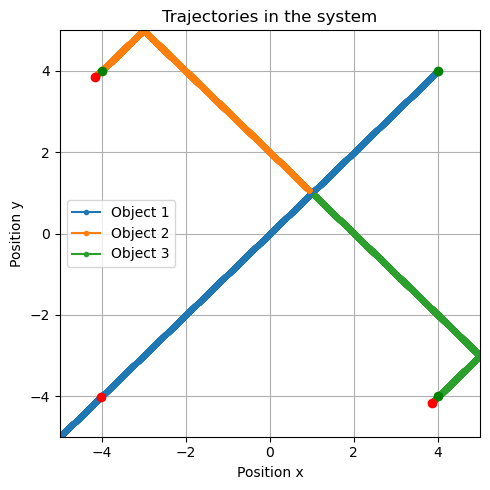

In [46]:
# Plot of trajectories in xy-plane
plt.figure(figsize=(5,5))
for i in range(N_objects):
    obj_i_positions = positions[:,i,:]
    plt.plot(obj_i_positions[:,0], obj_i_positions[:,1], marker='.', label=f'Object {i+1}')
    # Object starts at green dot, ends at red dot
    plt.plot(obj_i_positions[0,0], obj_i_positions[0,1], marker='.', color='green', markersize=12)
    plt.plot(obj_i_positions[-1,0], obj_i_positions[-1,1], marker='.', color='red', markersize=12)

plt.xlabel('Position x')
plt.ylabel('Position y')
plt.title('Trajectories in the system')
plt.legend()
plt.grid()
plt.xlim(-0.5*box_length, 0.5*box_length)
plt.ylim(-0.5*box_length, 0.5*box_length)
plt.tight_layout()
plt.show()

As we would like, object 1 moves into the opposite corner and is reflected back. Objects 2 and 3 bounce of the wall, collide with each other, move back and hit the wall once more before the simulation ends.

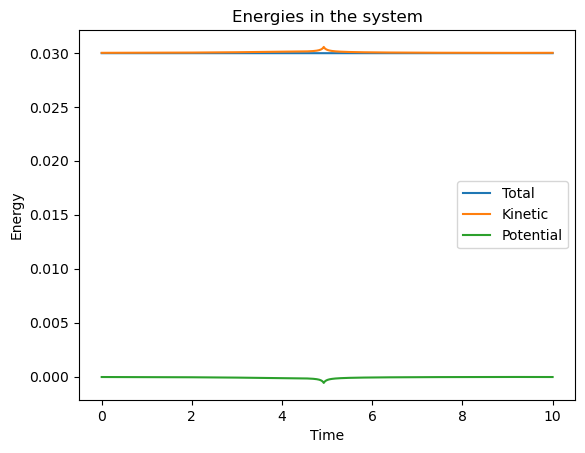

In [47]:
kinetic_per_particle = 0.5 * masses * np.sum(velocities**2, axis=2)
kinetic_total = np.sum(kinetic_per_particle, axis=1)

potential_total = np.zeros(shape=[N_steps])
for j in range(N_objects-1):  # don't need to consider the last object, is cancelled in next loop
    r_j = positions[:,j,:]
    
    for k in range(j+1, N_objects):  # start from the object after j
        if not periodic:
            r_k = positions[:,k,:]
            distance = np.linalg.norm(r_j - r_k, axis=1)  # distance between j and k at all timestep
        else:  # Apply minimal image convention
            copy_r_k = closest_copy_coordinates(r_j, positions[:,k,:])
            distance = np.linalg.norm(r_j - copy_r_k, axis=1)
        potential_jk = -G * masses[j] * masses[k] / distance
        potential_total += potential_jk

energy = kinetic_total + potential_total

plt.figure()
plt.plot(times, energy, label="Total")
plt.plot(times, kinetic_total, label="Kinetic")
plt.plot(times, potential_total, label="Potential")
plt.title("Energies in the system")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()

The energy also looks good, with only one bump in kinetic/potential energy when the collision between objects 2 and 3 occurs. No energy is lost in the wall collisions, as expected.